# Virtuális vesztes – gráfos gyakorló feladatok (sablon)

Ez a notebook gyakorló feladatokhoz készült. Ahol `TODO` jelölést látsz,
ott neked kell megírni a kódot.

GRAFIKUS ÁBRÁZOLÁS RÁD VAN BÍZVA, DE KELL!

## 1. feladat: Gráf és bináris élkódolás

In [21]:
# edges = [(u, v, w), ...] - w él súlya

edges = [
    (0, 1, 4),
    (0, 2, 2),
    (1, 2, 5),
    (1, 3, 10),
    (2, 3, 3)
]

num_edges = len(edges)
num_edges

5

## 2. feladat: Bináris egyed → költség

In [22]:
import heapq

def decode_edges(bitstring, edges):
    active_edges = []
    for i in range(len(bitstring)):
        if bitstring[i] == '1':
            active_edges.append(edges[i])
    return active_edges

def individual_cost(bitstring, edges, start=0, goal=None):
    active_edges = decode_edges(bitstring, edges)

    if not active_edges:
        return float('inf') # No active edges, no path

    all_nodes = set()
    for u, v, w in edges:
        all_nodes.add(u)
        all_nodes.add(v)
    if not all_nodes:
        return float('inf') # No nodes in graph

    max_node = max(all_nodes)

    if goal is None:
        goal = max_node

    graph = {i: [] for i in range(max_node + 1)}
    for u, v, w in active_edges:
        graph[u].append((v, w))
        # graph[v].append((u, w)) # Uncomment if graph is undirected

    distances = {node: float('inf') for node in range(max_node + 1)}
    distances[start] = 0
    priority_queue = [(0, start)]

    while priority_queue:
        current_distance, current_node = heapq.heappop(priority_queue)

        if current_distance > distances[current_node]:
            continue

        for neighbor, weight in graph[current_node]:
            distance = current_distance + weight
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                heapq.heappush(priority_queue, (distance, neighbor))

    return distances[goal]


**decode_edges** - a bináris vektorból (bitstring) kiválogatja az aktív éleket

**individual_cost** - a Dijkstra algoritmussal számítja ki a legrövidebb út költségét a kiválasztott élek alapján. Ha nincs út a start és goal között, akkor végtelen költséget ad vissza.

## 3. feladat: Populáció és gyenge egyedek

In [23]:
import random

def random_individual(num_edges):
    return ''.join(random.choice('01') for _ in range(num_edges))

def init_population(pop_size, num_edges):
    return [random_individual(num_edges) for _ in range(pop_size)]

def select_weak(population, costs, fraction=0.3):
    indexed_costs = list(enumerate(costs))

    indexed_costs.sort(key=lambda x: x[1], reverse=True)

    num_weak = int(len(population) * fraction)

    weak_individuals_indices = [idx for idx, _ in indexed_costs[:num_weak]]
    weak_individuals = [population[i] for i in weak_individuals_indices]

    return weak_individuals

**random_individual**- egy véletlen bináris vektort hoz létre, melynek hossza megegyezik az élek számával.

**init_population** - pop_size darab véletlen egyedből álló populációt inicializál.

 **select_weak** - a legmagasabb költségű egyedek (azaz a 'gyengék') kiválasztásáért felelős, a fraction paraméter alapján.


## 4. feladat: VL vektor kiszámítása

In [24]:
def compute_VL(weak_individuals, num_edges):
    VL = [0.0] * num_edges

    if not weak_individuals:
        return VL

    for individual in weak_individuals:
        for i in range(num_edges):
            if individual[i] == '1':
                VL[i] += 1

    for i in range(num_edges):
        VL[i] /= len(weak_individuals)

    return VL

## 5. feladat: VL frissítése

In [25]:
def update_VL(VL_old, VL_delta, alpha=0.5):
    if len(VL_old) != len(VL_delta):
        raise ValueError("VL_old and VL_delta must have the same length")

    updated_VL = []
    for i in range(len(VL_old)):
        updated_VL.append((1 - alpha) * VL_old[i] + alpha * VL_delta[i])
    return updated_VL

**update_VL** - a függvény a VL_old (előző VL vektor), a VL_delta (az aktuális gyenge egyedekből számított VL) és az alpha (tanulási ráta) paraméterek alapján frissíti a VL vektort a megadott képlet szerint: VL^{ t+1 } = (1-alpha) * VL_old + alpha * VL_delta.

## 6. feladat: VL-alapú mutáció

In [26]:
import random

def mutation_probabilities(individual, VL):
    probabilities = []
    for i in range(len(individual)):
        x_i = int(individual[i])
        p_i = 1 - abs(VL[i] - x_i)
        probabilities.append(p_i)
    return probabilities

def VL_mutation(individual, VL):
    mut_probs = mutation_probabilities(individual, VL)
    mutated_individual_list = list(individual)

    for i in range(len(mutated_individual_list)):
        if random.random() < mut_probs[i]:
            if mutated_individual_list[i] == '0':
                mutated_individual_list[i] = '1'
            else:
                mutated_individual_list[i] = '0'

    return ''.join(mutated_individual_list)

**mutation_probabilities** - az egyed bináris értékei és a VL vektor alapján számítja ki az egyes pozíciók mutációs valószínűségeit a megadott p_i = 1 - |VL_i - x_i| képlettel.

**VL_mutation** - ezeket a valószínűségeket felhasználva véletlenszerűen módosítja (mutálja) az egyed bitjeit. Minél nagyobb a mutációs valószínűség egy bitnél, annál valószínűbb, hogy átfordul (0-ból 1-be vagy fordítva).

## 7. feladat (nehéz): Mini EA VL-mutációval

In [27]:
def run_VL_EA(edges, pop_size=20, n_generations=50, alpha=0.5, start_node=0, goal_node=None):
    num_edges = len(edges)

    population = init_population(pop_size, num_edges)
    VL = [0.0] * num_edges

    best_individual_overall = None
    best_cost_overall = float('inf')
    cost_history = []

    print(f"Starting Mini EA with {n_generations} generations, population size {pop_size}, alpha {alpha}")

    for generation in range(n_generations):
        costs = [individual_cost(ind, edges, start=start_node, goal=goal_node) for ind in population]

        current_gen_best_cost = float('inf')
        current_gen_best_individual = None
        for i, cost in enumerate(costs):
            if cost < current_gen_best_cost:
                current_gen_best_cost = cost
                current_gen_best_individual = population[i]

        if current_gen_best_cost < best_cost_overall:
            best_cost_overall = current_gen_best_cost
            best_individual_overall = current_gen_best_individual

        cost_history.append(best_cost_overall)

        weak_individuals = select_weak(population, costs)

        VL_delta = compute_VL(weak_individuals, num_edges)

        VL = update_VL(VL, VL_delta, alpha)

        new_population = []

        if best_individual_overall is not None and best_cost_overall != float('inf'):
            new_population.append(best_individual_overall)
        else:
            new_population.append(random_individual(num_edges))

        while len(new_population) < pop_size:
            parent = random.choice(population)
            mutated_child = VL_mutation(parent, VL)
            new_population.append(mutated_child)

        population = new_population

    print(f"\nMini EA finished. Best cost found: {best_cost_overall}")
    print(f"Corresponding individual: {best_individual_overall}")
    return best_individual_overall, best_cost_overall, cost_history

In [28]:
print("Példa: decode_edges és individual_cost")
sample_bitstring = '10101' # Pl. a 0, 2 és 4. él aktív
print(f"Példa bináris egyed: {sample_bitstring}")

active_edges_sample = decode_edges(sample_bitstring, edges)
print(f"Aktív élek (decode_edges): {active_edges_sample}")

cost_sample = individual_cost(sample_bitstring, edges)
print(f"Költség (individual_cost): {cost_sample}\n")

print("Példa: random_individual és init_population")
sample_individual = random_individual(num_edges)
print(f"Egy véletlen egyed (random_individual): {sample_individual}")

pop_size = 5
initial_population = init_population(pop_size, num_edges)
print(f"Kezdeti populáció (init_population, {pop_size} egyed): {initial_population}\n")

print("Példa: select_weak")
population_costs = [individual_cost(ind, edges) for ind in initial_population]
print(f"Kezdeti populáció költségei: {population_costs}")

weak_fraction = 0.4
weak_individuals_selected = select_weak(initial_population, population_costs, fraction=weak_fraction)
print(f"Kiválasztott gyenge egyedek (select_weak, {weak_fraction*100}%): {weak_individuals_selected}\n")

print("Példa: compute_VL")
if weak_individuals_selected:
    vl_vector = compute_VL(weak_individuals_selected, num_edges)
    print(f"VL vektor a gyenge egyedekből (compute_VL): {vl_vector}")
else:
    print("Nincsenek gyenge egyedek a VL vektor számításához.")

print("\nPélda: update_VL")
vl_old_example = [0.1, 0.2, 0.3, 0.4, 0.5]
vl_delta_example = [0.6, 0.7, 0.8, 0.9, 0.0]
alpha_example = 0.5
updated_vl_example = update_VL(vl_old_example, vl_delta_example, alpha_example)
print(f"Régi VL (VL_old): {vl_old_example}")
print(f"VL delta (VL_delta): {vl_delta_example}")
print(f"Alpha: {alpha_example}")
print(f"Frissített VL (update_VL): {updated_vl_example}\n")

print("Példa: mutation_probabilities és VL_mutation")
individual_to_mutate = '01010'
mutation_probs = mutation_probabilities(individual_to_mutate, vl_vector)
print(f"Mutálandó egyed: {individual_to_mutate}")
print(f"Mutációs valószínűségek (mutation_probabilities): {mutation_probs}")

mutated_individual = VL_mutation(individual_to_mutate, vl_vector)
print(f"Mutált egyed (VL_mutation): {mutated_individual}\n")

print("Példa: run_VL_EA algoritmus futtatása")
best_ind, best_cost, history = run_VL_EA(edges, pop_size=10, n_generations=20, alpha=0.5, start_node=0, goal_node=3)

print(f"\nAz EA futtatásának eredménye:")
print(f"Legjobb talált egyed: {best_ind}")
print(f"Legjobb költség: {best_cost}")

Példa: decode_edges és individual_cost
Példa bináris egyed: 10101
Aktív élek (decode_edges): [(0, 1, 4), (1, 2, 5), (2, 3, 3)]
Költség (individual_cost): 12

Példa: random_individual és init_population
Egy véletlen egyed (random_individual): 00110
Kezdeti populáció (init_population, 5 egyed): ['10010', '01111', '11001', '00010', '11010']

Példa: select_weak
Kezdeti populáció költségei: [14, 5, 5, inf, 14]
Kiválasztott gyenge egyedek (select_weak, 40.0%): ['00010', '10010']

Példa: compute_VL
VL vektor a gyenge egyedekből (compute_VL): [0.5, 0.0, 0.0, 1.0, 0.0]

Példa: update_VL
Régi VL (VL_old): [0.1, 0.2, 0.3, 0.4, 0.5]
VL delta (VL_delta): [0.6, 0.7, 0.8, 0.9, 0.0]
Alpha: 0.5
Frissített VL (update_VL): [0.35, 0.44999999999999996, 0.55, 0.65, 0.25]

Példa: mutation_probabilities és VL_mutation
Mutálandó egyed: 01010
Mutációs valószínűségek (mutation_probabilities): [0.5, 0.0, 1.0, 1.0, 1.0]
Mutált egyed (VL_mutation): 01101

Példa: run_VL_EA algoritmus futtatása
Starting Mini EA with 

### Az optimális megoldás vizuális ábrázolása a gráfon

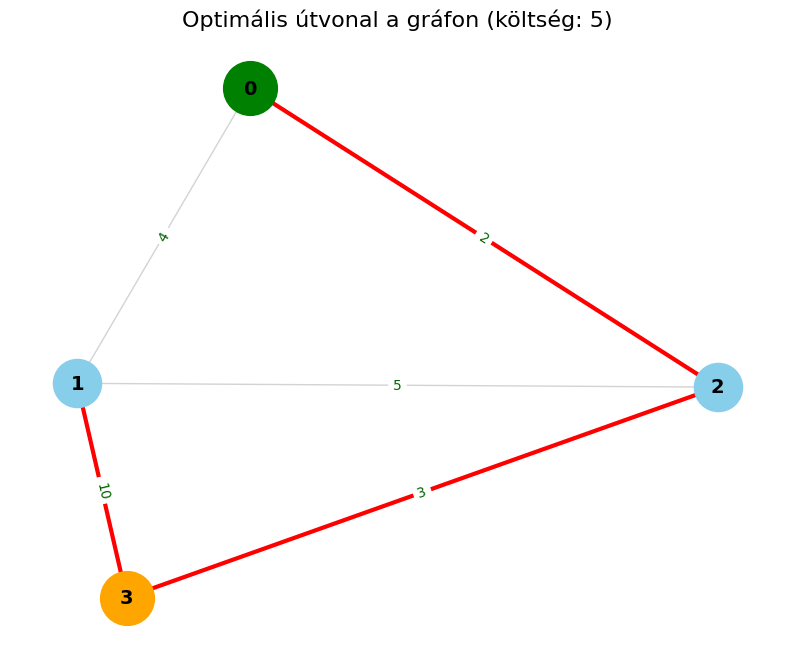

In [32]:
import networkx as nx
import matplotlib.pyplot as plt

G_solution = nx.Graph()
for u, v, w in edges:
    G_solution.add_edge(u, v, weight=w)

solution_edges_tuples = decode_edges(best_ind, edges)

solution_edges_uv = [(u, v) for u, v, w in solution_edges_tuples]

pos = nx.spring_layout(G_solution)

plt.figure(figsize=(10, 8))

nx.draw_networkx_nodes(G_solution, pos, node_color='skyblue', node_size=1200)

nx.draw_networkx_edges(G_solution, pos, width=1, edge_color='lightgray')

nx.draw_networkx_edges(G_solution, pos, edgelist=solution_edges_uv, width=3, edge_color='red')

nx.draw_networkx_labels(G_solution, pos, font_size=14, font_weight='bold')

edge_labels = nx.get_edge_attributes(G_solution, 'weight')
nx.draw_networkx_edge_labels(G_solution, pos, edge_labels=edge_labels, font_color='darkgreen', font_size=10)

start_node_ea = 0
goal_node_ea = 3

nx.draw_networkx_nodes(G_solution, pos, nodelist=[start_node_ea], node_color='green', node_size=1500, label='Start')
nx.draw_networkx_nodes(G_solution, pos, nodelist=[goal_node_ea], node_color='orange', node_size=1500, label='Goal')

plt.title(f'Optimális útvonal a gráfon (költség: {best_cost})', size=16)
plt.axis('off')
plt.show()